In [84]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import os

In [85]:
data = pd.read_csv('df_arabica_clean.csv',index_col='ID')


In [86]:
data

,Unnamed: 0,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
ID,,,,,,,,,,,,,,,,,,,,,
0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,曾福森,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,202,Brazil,Fazenda Conquista,019/22,Dry Mill,NaN,Ipanema Coffees,950,Sul de Minas,Ipanema Coffees,...,80.08,11.4,0,0,green,4,"February 2nd, 2024",Brazil Specialty Coffee Association,"Rua Gaspar Batista Paiva, 416 – Santa Luiza Va...",Chris Allen - 55 35 3212-4705
203,203,Nicaragua,Finca San Felipe,017-053-0155,Beneficio Atlantic Sébaco,017-053-0155,Exportadora Atlantic S.A,1200,Matagalpa,Exportadora Atlantic S.A.,...,80.00,10.4,0,2,green,12,"March 2nd, 2024",Asociación de Cafés Especiales de Nicaragua,"Del Hotel Seminole 2 C al lago, 1 C arriba.",Maria Ines Benavidez Toval - 011-(505)-8396 4717
204,204,Laos,-,105/3/VL7285-005,DRY MILL,105/3/VL7285-005,Marubeni Corporation,1300,Bolaven Plateau,"LAO MINH TIEN COFFEE SOLE CO.,LTD",...,79.67,11.6,0,9,green,11,"November 11th, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


'Unnamed: 0' column seems wrong we'll drop that

In [87]:
data.drop(columns='Unnamed: 0',inplace=True)

In [88]:
data

,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,Number of Bags,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
ID,,,,,,,,,,,,,,,,,,,,,
0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,1,...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,曾福森,1,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,19,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",Santa Maria de Dota,1,...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",Camilo Merizalde,2,...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,Brazil,Fazenda Conquista,019/22,Dry Mill,NaN,Ipanema Coffees,950,Sul de Minas,Ipanema Coffees,2240,...,80.08,11.4,0,0,green,4,"February 2nd, 2024",Brazil Specialty Coffee Association,"Rua Gaspar Batista Paiva, 416 – Santa Luiza Va...",Chris Allen - 55 35 3212-4705
203,Nicaragua,Finca San Felipe,017-053-0155,Beneficio Atlantic Sébaco,017-053-0155,Exportadora Atlantic S.A,1200,Matagalpa,Exportadora Atlantic S.A.,300,...,80.00,10.4,0,2,green,12,"March 2nd, 2024",Asociación de Cafés Especiales de Nicaragua,"Del Hotel Seminole 2 C al lago, 1 C arriba.",Maria Ines Benavidez Toval - 011-(505)-8396 4717
204,Laos,-,105/3/VL7285-005,DRY MILL,105/3/VL7285-005,Marubeni Corporation,1300,Bolaven Plateau,"LAO MINH TIEN COFFEE SOLE CO.,LTD",343,...,79.67,11.6,0,9,green,11,"November 11th, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


In [89]:
data.columns

Index(['Country of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number',
       'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags',
       'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date',
       'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor',
       'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup',
       'Sweetness', 'Overall', 'Defects', 'Total Cup Points',
       'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color',
       'Category Two Defects', 'Expiration', 'Certification Body',
       'Certification Address', 'Certification Contact'],
      dtype='object')

# **Information about the columns are below:**

    Aroma: Refers to the scent or fragrance of the coffee.
    Flavor: The flavor of coffee is evaluated based on the taste, including any sweetness, bitterness, acidity, and other flavor notes.
    Aftertaste: Refers to the lingering taste that remains in the mouth after swallowing the coffee.
    Acidity: Acidity in coffee refers to the brightness or liveliness of the taste.
    Body: The body of coffee refers to the thickness or viscosity of the coffee in the mouth.
    Balance: Balance refers to how well the different flavor components of the coffee work together.
    Uniformity: Uniformity refers to the consistency of the coffee from cup to cup.
    Clean Cup: A clean cup refers to a coffee that is free of any off-flavors or defects, such as sourness, mustiness, or staleness.
    Sweetness: It can be described as caramel-like, fruity, or floral, and is a desirable quality in coffee.

# First question:
    What is the distribution of coffee origins in the dataset?
    

<Axes: title={'center': 'Distribution of Coffee Origins'}, xlabel='Country of Origin'>

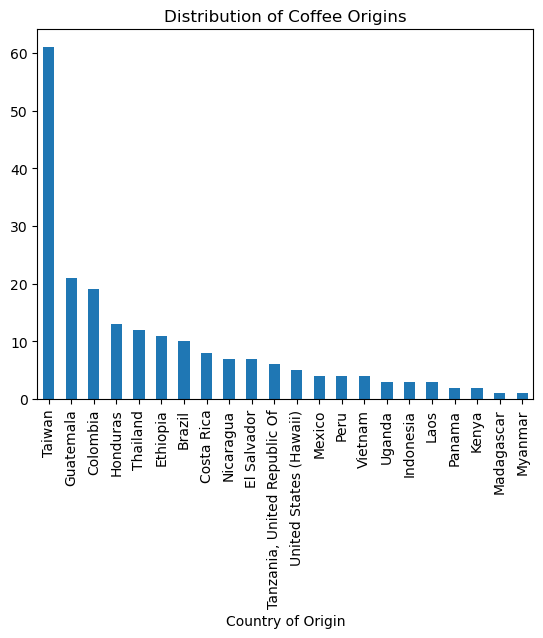

In [90]:
data['Country of Origin'].value_counts().plot(kind='bar',title='Distribution of Coffee Origins')

# Second Question
    How does the altitude of the coffee farms affect the overall quality of the coffee?

In [91]:
data['Altitude'].dtype

dtype('O')

This columns type is object which means the items in this column are strings. But it should be floats so that we can work on them. So we'll convert it


In [92]:
data['Altitude']

ID
0      1700-1930
1           1200
2           1300
3           1900
4      1850-2100
         ...    
202          950
203         1200
204         1300
205         1200
206     850-1100
Name: Altitude, Length: 207, dtype: object

Now we can't directly convert the type from strings to floats because we have values that contains '-' in them. We'll take care of that but firstly I discovered that we have a single column which has a value of '4895 A 5650'. So let me fix that separately.

In [93]:
for i in data['Altitude']:
    if '~' in str(i):
        print(i)

1200~1600


In [94]:
data.loc[data['Altitude']== '4895 A 5650','Altitude'] = '4895-5650'
data.loc[data['Altitude']== '1200~1600','Altitude'] = '1200-1600'

I think its time to take a copy of the dataframe because we made little changes and we don't want to ruin our data. So we'll work on the copy after here

In [95]:
datac1= data.copy()

In [96]:
datac1['Altitude']

ID
0      1700-1930
1           1200
2           1300
3           1900
4      1850-2100
         ...    
202          950
203         1200
204         1300
205         1200
206     850-1100
Name: Altitude, Length: 207, dtype: object

In [97]:
def convert_altitude(altitude):
    if '-' in str(altitude):
        alt_range = altitude.split(sep='-')
        return(float(alt_range[0]) + float(alt_range[1]) / 2)
    
    else:
        return float(altitude)
    

datac1['Altitude'] = datac1['Altitude'].apply(convert_altitude)

In [98]:
datac1['Altitude']

ID
0      2665.0
1      1200.0
2      1300.0
3      1900.0
4      2900.0
        ...  
202     950.0
203    1200.0
204    1300.0
205    1200.0
206    1400.0
Name: Altitude, Length: 207, dtype: float64

We've changed the type so finally we can answer the question by findind the correlation.

0.09787069609454258

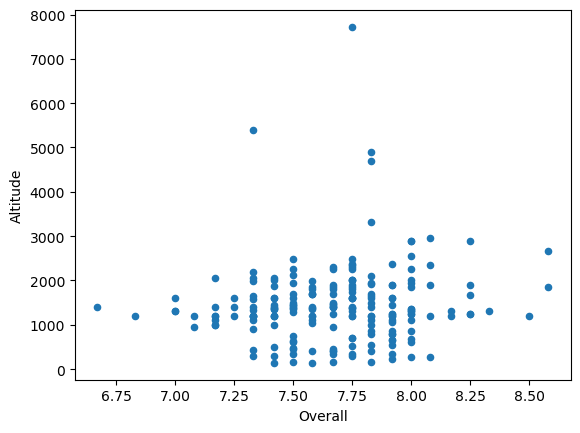

In [99]:
datac1[['Altitude','Overall']].plot(kind='scatter',x='Overall',y='Altitude')
datac1['Altitude'].corr(data['Overall'])

We can see that there is 0,09 correlation between attitude and overall points. We can assume that there is no relation between them. 

# Question 3

    Which regions are known for producing the highest-rated coffees?
    

For this question we'll look at 'Region' and 'Overall' columns

In [100]:
datac1.groupby(by='Region')['Overall'].mean()[:5]

Region
( Dongshan Dist., Tainan City)    7.75
ANTIGUA GUATEMALA                 7.79
ARUSHA                            7.75
Acatenango                        8.00
Aceh Tengah                       7.83
Name: Overall, dtype: float64

These are Regions of top 5 highest rated coffees.

# Question 4
    Who are the prominent producers in the dataset?

In [101]:
datac1['Producer'].value_counts()[:10]

Producer
Doi Tung Development Project    7
Roselia Yglesias                3
Fausto Nahun Maldonado          3
Martin Gutierrez                3
J.J. Borja Nathan, S.A.         3
Omar Acosta                     2
Cafetalera Paquim, S.A.         2
蘇甘永                             2
Sandro Crispin Espiritu         2
NicaNoLA Coffee                 2
Name: count, dtype: int64

# Question 5
    What is the average number of bags per lot in the dataset?

In [102]:
datac1.groupby(by='Lot Number')['Number of Bags'].mean()

Lot Number
001                                        141.0
002                                         32.0
002/1738/0029                              440.0
0038                                       440.0
004/22                                     960.0
                                           ...  
The 2022 Pacific Rim Coffee Summit,VN02      3.0
VHA- S3                                     22.0
Washed Limmu                               320.0
屏東縣三地門鄉德文段                                   1.0
屏東縣瑪家鄉                                       1.0
Name: Number of Bags, Length: 187, dtype: float64

# Question 6
    How does the bag weight vary across different lots?

In [103]:
datac1['Bag Weight']

ID
0      35 kg
1      80 kg
2      25 kg
3      22 kg
4      24 kg
       ...  
202    60 kg
203    30 kg
204    60 kg
205     2 kg
206    60 kg
Name: Bag Weight, Length: 207, dtype: object

We can convert these into float numbers in order to work with them

In [123]:
def convert_weights(weight):
    if type(weight) is not float:
        return float(weight[:-2])
    else:
        return weight
    
datac1['Bag Weight']= datac1['Bag Weight'].apply(convert_weights)

In [124]:
datac1['Bag Weight']

ID
0      35.0
1      80.0
2      25.0
3      22.0
4      24.0
       ... 
202    60.0
203    30.0
204    60.0
205     2.0
206    60.0
Name: Bag Weight, Length: 207, dtype: float64

In [128]:
datac1.groupby(by='Lot Number')['Bag Weight'].mean()

Lot Number
001                                        69.0
002                                        69.0
002/1738/0029                              60.0
0038                                       60.0
004/22                                     60.0
                                           ... 
The 2022 Pacific Rim Coffee Summit,VN02     5.0
VHA- S3                                    60.0
Washed Limmu                               60.0
屏東縣三地門鄉德文段                                  2.0
屏東縣瑪家鄉                                      2.0
Name: Bag Weight, Length: 187, dtype: float64

# **MORE COMPLEX QUESTİONS**

# Question 7
    Can you identify any specific patterns or relationships between the sensory attributes (aroma, flavor, aftertaste, acidity, body, balance, uniformity, cleanliness, sweetness) and the overall quality of the coffee?
    

<Axes: >

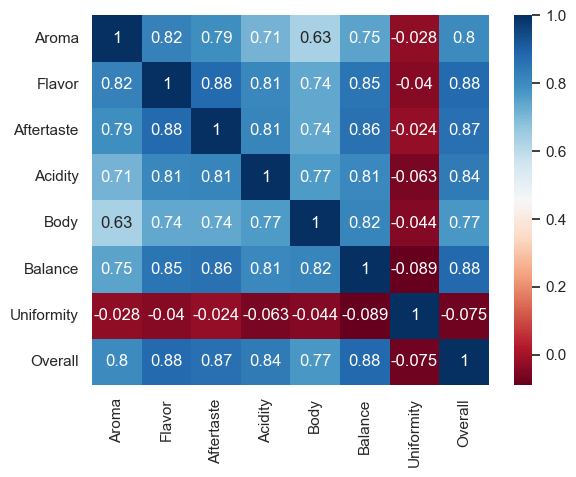

In [168]:
corr= datac1[['Aroma', 'Flavor',
       'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity'
       , 'Overall']].corr()


sns.heatmap(data=corr,annot=True,cmap='RdBu')



# Question 8
    Is there a significant difference in the sensory attributes of coffees from different regions or farms? If so, which attributes contribute the most to this variation?

In [175]:
sensory_attributes = ['Aroma', 'Flavor',
       'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity'
       , 'Overall']

datac1.groupby(by=['Region','Farm Name'])[sensory_attributes].mean().sort_values(by='Overall',ascending=False)

Aroma   
Region                                         Farm Name                                      
Piendamo,Cauca                                 Finca El Paraiso                        8.58  \
Chiayi                                         Royal Bean Geisha Estate                8.50   
Laos Borofen Plateau                           OKLAO coffee farms                      8.33   
Chiayi                                         野牡丹咖啡莊園 Melastoma Coffee Estate         8.33   
                                               亮軒咖啡莊園 Liang Xuan Coffee Farm           8.08   
...                                                                                     ...   
Volcan Chinchontepek, San Vicente, El Salvador Rosario de Maria II, Area de Menjivar   7.08   
Chanchamayo, Lamerced                          Fundo La Libertad                       7.50   
Bolaven Plateau                                -                                       7.25   
Volcan de San Vicente, La Paz, El Salvador     Rosario de Maria II, Area de La Pila    6.50   
Minas Gerais                                   Walter Matter                           7.25   

                                                                                      Flavor   
Region                                         Farm Name                                       
Piendamo,Cauca                                 Finca El Paraiso                         8.50  \
Chiayi                                         Royal Bean Geisha Estate                 8.50   
Laos Borofen Plateau                           OKLAO coffee farms                       8.42   
Chiayi                                         野牡丹咖啡莊園 Melastoma Coffee Estate          8.17   
                                               亮軒咖啡莊園 Liang Xuan Coffee Farm            8.08   
...                                                                                      ...   
Volcan Chinchontepek, San Vicente, El Salvador Rosario de Maria II, Area de Menjivar    7.25   
Chanchamayo, Lamerced                          Fundo La Libertad                        7.25   
Bolaven Plateau                                -                                        7.17   
Volcan de San Vicente, La Paz, El Salvador     Rosario de Maria II, Area de La Pila     6.75   
Minas Gerais                                   Walter Matter                            7.08   

                                                                                      Aftertaste   
Region                                         Farm Name                                           
Piendamo,Cauca                                 Finca El Paraiso                             8.42  \
Chiayi                                         Royal Bean Geisha Estate                     7.92   
Laos Borofen Plateau                           OKLAO coffee farms                           8.08   
Chiayi                                         野牡丹咖啡莊園 Melastoma Coffee Estate              8.08   
                                               亮軒咖啡莊園 Liang Xuan Coffee Farm                8.25   
...                                                                                          ...   
Volcan Chinchontepek, San Vicente, El Salvador Rosario de Maria II, Area de Menjivar        7.08   
Chanchamayo, Lamerced                          Fundo La Libertad                            7.17   
Bolaven Plateau                                -                                            7.08   
Volcan de San Vicente, La Paz, El Salvador     Rosario de Maria II, Area de La Pila         6.75   
Minas Gerais                                   Walter Matter                                6.67   

                                                                                      Acidity   
Region                                         Farm Name                                        
Piendamo,Cauca                                 Finca El Paraiso                          8.58  \
Chiayi   